In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/adl-07-cam0-rgb/adl-07-cam0-rgb-057.png
/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/adl-07-cam0-rgb/adl-07-cam0-rgb-034.png
/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/adl-07-cam0-rgb/adl-07-cam0-rgb-178.png
/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/adl-07-cam0-rgb/adl-07-cam0-rgb-126.png
/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/adl-07-cam0-rgb/adl-07-cam0-rgb-002.png
/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/adl-07-cam0-rgb/adl-07-cam0-rgb-103.png
/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb/adl-07-cam0-rgb/adl-07-cam0-rgb-153.png
/kaggle/input/datasets/shahliza27/ur-fall-detection-dat

In [2]:
!pip install mediapipe==0.10.14 -q

# mediapipe's __init__.py unconditionally imports mediapipe.tasks, which pulls in
# TensorFlow, which needs a newer protobuf than mediapipe itself installs — causing
# a crash. We only need mediapipe.solutions.pose, never .tasks, so we disable that
# one import line directly in the installed package file.
init_file = "/usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py"

with open(init_file, "r") as f:
    content = f.read()

content = content.replace(
    "import mediapipe.tasks.python as tasks",
    "# import mediapipe.tasks.python as tasks  # patched out — avoids TF/protobuf conflict"
)

with open(init_file, "w") as f:
    f.write(content)

print("Patched. Restart the kernel now before running anything else.")

Patched. Restart the kernel now before running anything else.


In [3]:
import mediapipe as mp
print("mediapipe version:", mp.__version__)
print("solutions available:", hasattr(mp, "solutions"))

mediapipe version: 0.10.14
solutions available: True


# **OPTION A: FAST PATH: skips extraction + windowing entirely**

In [4]:
import shutil
import numpy as np

SRC = "/kaggle/input/datasets/sanyaa11/le2i-urfd-combined-data-backup"
for fname in os.listdir(SRC):
    shutil.copy(os.path.join(SRC, fname), f"/kaggle/working/{fname}")

X = np.load('/kaggle/working/X_combined.npy')
y = np.load('/kaggle/working/y_combined.npy')

print(f"Restored — X shape: {X.shape}, fall%: {y.mean()*100:.1f}%")

Restored — X shape: (2967, 30, 99), fall%: 14.6%


In [5]:
from sklearn.model_selection import train_test_split

# Normalize per coordinate, across the WHOLE dataset — each of the 99 values
# gets its own mean/std, computed once, then applied everywhere (train/val/test).
# Why compute stats on the full X now, before splitting: this is a borderline
# but common simplification — the "fully rigorous" version computes mean/std
# from TRAIN only, to avoid any leakage from val/test into normalization.
# We'll do it properly: split first, then normalize using train stats only.

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# Compute normalization stats from TRAIN ONLY — never let val/test influence this
mean = X_train.mean(axis=(0, 1))   # shape (99,)
std = X_train.std(axis=(0, 1)) + 1e-8

X_train = (X_train - mean) / std
X_val   = (X_val - mean) / std
X_test  = (X_test - mean) / std

# Save these — needed again at inference time on any new video
np.save('/kaggle/working/norm_mean.npy', mean)
np.save('/kaggle/working/norm_std.npy', std)

print(f"Train: {X_train.shape} | fall%: {y_train.mean()*100:.1f}%")
print(f"Val  : {X_val.shape}   | fall%: {y_val.mean()*100:.1f}%")
print(f"Test : {X_test.shape}  | fall%: {y_test.mean()*100:.1f}%")

Train: (2373, 30, 99) | fall%: 14.6%
Val  : (297, 30, 99)   | fall%: 14.8%
Test : (297, 30, 99)  | fall%: 14.5%


In [6]:
import torch
import numpy as np
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

class FallDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]


# Weighted sampling: makes the model see fall/ADL examples roughly equally
# often per batch, even though falls are only ~12% of the real data.
# Without this, the model could get high accuracy just by always predicting
# "ADL" — technically correct 88% of the time, but useless for detecting falls.
class_counts = np.bincount(y_train)
weights = 1.0 / class_counts
sample_weights = weights[y_train]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = DataLoader(FallDataset(X_train, y_train), batch_size=32, sampler=sampler)
val_loader   = DataLoader(FallDataset(X_val, y_val), batch_size=32, shuffle=False)
test_loader  = DataLoader(FallDataset(X_test, y_test), batch_size=32, shuffle=False)

print(f"Class counts (train): {class_counts}")
print(f"Sample weights range: {sample_weights.min():.4f} to {sample_weights.max():.4f}")

Class counts (train): [2027  346]
Sample weights range: 0.0005 to 0.0029


In [8]:
class FallLSTM(nn.Module):
    """
    Bidirectional LSTM with attention for fall detection.
    Input : (batch, 30, 99)  — 30 frames x 33 joints x (x,y,z)
    Output: (batch, 2)       — logits for [ADL, FALL]
    """
    def __init__(self, input_dim=99, hidden_dim=64, num_layers=2, num_classes=2, dropout=0.4):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True    # reads the sequence forward AND backward
        )

        # Attention: lets the model weigh WHICH frames in the window mattered most,
        # instead of only using the last frame's hidden state
        self.attention = nn.Linear(hidden_dim * 2, 1)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)                          # (batch, 30, hidden_dim*2)
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)  # (batch, 30, 1)
        context = (lstm_out * attn_weights).sum(dim=1)       # weighted sum over time -> (batch, hidden_dim*2)
        return self.classifier(context)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FallLSTM().to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Device: {device}")
print(f"Parameters: {total_params:,}")
print(model)

Device: cpu
Parameters: 188,131
FallLSTM(
  (lstm): LSTM(99, 64, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (attention): Linear(in_features=128, out_features=1, bias=True)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [9]:
#Setup: fresh model, loss, optimizer, scheduler
from sklearn.metrics import f1_score, recall_score, precision_score

# Weighted loss: penalize missing a fall MORE than a false alarm.
# For a safety system, a missed fall (false negative) is far worse
# than an unnecessary alert (false positive).
class_counts_arr = np.bincount(y_train)
fall_weight = class_counts_arr[0] / class_counts_arr[1]   # ADL_count / FALL_count
print(f"Fall class weight: {fall_weight:.2f}x")

model = FallLSTM().to(device)   # fresh model — don't reuse old weights
criterion = nn.CrossEntropyLoss(weight=torch.FloatTensor([1.0, fall_weight]).to(device))
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

MAX_EPOCHS = 100
PATIENCE = 25  # stop if val F1 doesn't improve for 15 consecutive epochs

Fall class weight: 5.86x


In [10]:
#Training loop with early stopping
best_val_f1 = 0.0
epochs_without_improvement = 0
history = []

for epoch in range(MAX_EPOCHS):
    # --- Train ---
    model.train()
    train_loss = 0.0
    train_preds, train_true = [], []
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        logits = model(X_b)
        loss = criterion(logits, y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # prevents exploding gradients
        optimizer.step()
        train_loss += loss.item()
        train_preds.extend(logits.argmax(1).cpu().numpy())
        train_true.extend(y_b.cpu().numpy())
    avg_train_loss = train_loss / len(train_loader)

    # --- Validate ---
    model.eval()
    val_loss = 0.0
    val_preds, val_true = [], []
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            logits = model(X_b)
            loss = criterion(logits, y_b)
            val_loss += loss.item()
            val_preds.extend(logits.argmax(1).cpu().numpy())
            val_true.extend(y_b.cpu().numpy())
    avg_val_loss = val_loss / len(val_loader)

    # --- Metrics ---
    train_acc = np.mean(np.array(train_preds) == np.array(train_true))
    val_f1 = f1_score(val_true, val_preds, pos_label=1, zero_division=0)
    val_recall = recall_score(val_true, val_preds, pos_label=1, zero_division=0)
    val_precision = precision_score(val_true, val_preds, pos_label=1, zero_division=0)

    history.append({"epoch": epoch, "train_loss": avg_train_loss, "val_loss": avg_val_loss,
                     "train_acc": train_acc, "val_f1": val_f1,
                     "val_recall": val_recall, "val_precision": val_precision})

    # --- Checkpoint + early stopping tracking ---
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_without_improvement = 0
        torch.save(model.state_dict(), '/kaggle/working/fall_lstm_best.pt')
    else:
        epochs_without_improvement += 1

    scheduler.step(val_f1)

    if epoch % 5 == 0 or epoch == MAX_EPOCHS - 1:
        print(f"Epoch {epoch:3d} | Train Loss {avg_train_loss:.4f} | Val Loss {avg_val_loss:.4f} | "
              f"Train {train_acc:.3f} | Val F1 {val_f1:.3f} | Recall {val_recall:.3f} | "
              f"Precision {val_precision:.3f}{'  <- best' if epochs_without_improvement == 0 else ''}")

    # --- Early stopping check ---
    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} — no improvement for {PATIENCE} epochs")
        break

print(f"\nTraining done. Best Val F1: {best_val_f1:.3f}")

Epoch   0 | Train Loss 0.3891 | Val Loss 0.8147 | Train 0.545 | Val F1 0.307 | Recall 0.977 | Precision 0.182  <- best
Epoch   5 | Train Loss 0.1425 | Val Loss 0.6044 | Train 0.863 | Val F1 0.494 | Recall 0.886 | Precision 0.342  <- best
Epoch  10 | Train Loss 0.0896 | Val Loss 0.6662 | Train 0.908 | Val F1 0.544 | Recall 0.773 | Precision 0.420
Epoch  15 | Train Loss 0.0889 | Val Loss 0.7255 | Train 0.924 | Val F1 0.571 | Recall 0.818 | Precision 0.439
Epoch  20 | Train Loss 0.0323 | Val Loss 1.2092 | Train 0.980 | Val F1 0.651 | Recall 0.636 | Precision 0.667
Epoch  25 | Train Loss 0.0352 | Val Loss 1.4763 | Train 0.945 | Val F1 0.559 | Recall 0.705 | Precision 0.463
Epoch  30 | Train Loss 0.0249 | Val Loss 1.6754 | Train 0.979 | Val F1 0.682 | Recall 0.659 | Precision 0.707
Epoch  35 | Train Loss 0.0206 | Val Loss 1.8645 | Train 0.965 | Val F1 0.577 | Recall 0.682 | Precision 0.500
Epoch  40 | Train Loss 0.0189 | Val Loss 1.8696 | Train 0.971 | Val F1 0.561 | Recall 0.682 | Precisio

In [11]:
# from sklearn.metrics import f1_score, recall_score, precision_score
# """
# Weighted loss: penalize missing a fall MORE than a false alarm.
# For a safety system, a missed fall (false negative) is far worse
# than an unnecessary alert (false positive).
# """
# class_counts_arr = np.bincount(y_train)
# fall_weight = class_counts_arr[0] / class_counts_arr[1]   # ADL_count / FALL_count
# print(f"Fall class weight: {fall_weight:.2f}x")

# criterion = nn.CrossEntropyLoss(weight=torch.FloatTensor([1.0, fall_weight]).to(device))
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

# EPOCHS = 40
# best_val_f1 = 0.0
# history = []

# for epoch in range(EPOCHS):
#     # --- Train ---
#     model.train()
#     train_loss = 0.0
#     train_preds, train_true = [], []

#     for X_b, y_b in train_loader:
#         X_b, y_b = X_b.to(device), y_b.to(device)
#         optimizer.zero_grad()
#         logits = model(X_b)
#         loss = criterion(logits, y_b)
#         loss.backward()
#         nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # prevents exploding gradients
#         optimizer.step()

#         train_loss += loss.item()
#         train_preds.extend(logits.argmax(1).cpu().numpy())
#         train_true.extend(y_b.cpu().numpy())

#     # Average training loss
#     avg_train_loss = train_loss / len(train_loader)
    
#     # --- Validate ---
#     model.eval()
#     val_loss = 0.0
#     val_preds, val_true = [], []
#     with torch.no_grad():
#         for X_b, y_b in val_loader:
#             X_b = X_b.to(device)
#             y_b = y_b.to(device)

#             logits = model(X_b)

#             # Calculate validation loss
#             loss = criterion(logits, y_b)

#             val_loss += loss.item()
#             val_preds.extend(logits.argmax(1).cpu().numpy())
#             val_true.extend(y_b.cpu().numpy())

#     # Average validation loss
#     avg_val_loss = val_loss / len(val_loader)

#     train_acc = np.mean(np.array(train_preds) == np.array(train_true))
#     val_f1 = f1_score(val_true, val_preds, pos_label=1, zero_division=0)
#     val_recall = recall_score(val_true, val_preds, pos_label=1, zero_division=0)
#     val_precision = precision_score(val_true, val_preds, pos_label=1, zero_division=0)

#     history.append({"epoch": epoch, "train_loss": avg_train_loss, "val_loss": avg_val_loss, "train_acc": train_acc, "val_f1": val_f1,
#                      "val_recall": val_recall, "val_precision": val_precision})

#     if val_f1 > best_val_f1:
#         best_val_f1 = val_f1
#         torch.save(model.state_dict(), '/kaggle/working/fall_lstm_best.pt')

#     scheduler.step(val_f1)

#     if epoch % 5 == 0 or epoch == EPOCHS - 1:
#         print(
#             f"Epoch {epoch:3d} | "
#             f"Train Loss {avg_train_loss:.4f} | "
#             f"Val Loss {avg_val_loss:.4f} | "
#             f"Train {train_acc:.3f} | "
#             f"Val F1 {val_f1:.3f} | "
#             f"Recall {val_recall:.3f} | "
#             f"Precision {val_precision:.3f}"
#             f"{'  <- best' if val_f1 == best_val_f1 else ''}"
#         )

# print(f"\nTraining done. Best Val F1: {best_val_f1:.3f}")

In [12]:
#Test set evaluation
from sklearn.metrics import classification_report, confusion_matrix

model.load_state_dict(torch.load('/kaggle/working/fall_lstm_best.pt'))
model.eval()

test_preds, test_true = [], []
with torch.no_grad():
    for X_b, y_b in test_loader:
        logits = model(X_b.to(device))
        test_preds.extend(logits.argmax(1).cpu().numpy())
        test_true.extend(y_b.numpy())

print("=== TEST SET RESULTS ===\n")
print(classification_report(test_true, test_preds, target_names=['ADL', 'FALL'], digits=3))

cm = confusion_matrix(test_true, test_preds)
tn, fp, fn, tp = cm.ravel()
print(f"True ADL, predicted ADL   : {tn}")
print(f"True ADL, predicted FALL  : {fp}  (false alarm)")
print(f"True FALL, predicted ADL  : {fn}  <- missed fall")
print(f"True FALL, predicted FALL : {tp}")

=== TEST SET RESULTS ===

              precision    recall  f1-score   support

         ADL      0.957     0.961     0.959       254
        FALL      0.762     0.744     0.753        43

    accuracy                          0.929       297
   macro avg      0.859     0.852     0.856       297
weighted avg      0.929     0.929     0.929       297

True ADL, predicted ADL   : 244
True ADL, predicted FALL  : 10  (false alarm)
True FALL, predicted ADL  : 11  <- missed fall
True FALL, predicted FALL : 32


In [13]:
import torch.nn.functional as F

model.load_state_dict(torch.load('/kaggle/working/fall_lstm_best.pt'))
model.eval()

val_probs, val_true = [], []
with torch.no_grad():
    for X_b, y_b in val_loader:
        logits = model(X_b.to(device))
        probs = F.softmax(logits, dim=1)[:, 1]  # probability of FALL class
        val_probs.extend(probs.cpu().numpy())
        val_true.extend(y_b.numpy())

val_probs = np.array(val_probs)
val_true = np.array(val_true)

print("Threshold |  Recall | Precision |   F1")
print("-" * 45)
for threshold in [0.5, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15]:
    preds = (val_probs >= threshold).astype(int)
    r = recall_score(val_true, preds, pos_label=1, zero_division=0)
    p = precision_score(val_true, preds, pos_label=1, zero_division=0)
    f1 = f1_score(val_true, preds, pos_label=1, zero_division=0)
    print(f"  {threshold:.2f}    |  {r:.3f}  |   {p:.3f}   |  {f1:.3f}")

Threshold |  Recall | Precision |   F1
---------------------------------------------
  0.50    |  0.659  |   0.725   |  0.690
  0.40    |  0.705  |   0.508   |  0.590
  0.35    |  0.705  |   0.508   |  0.590
  0.30    |  0.705  |   0.508   |  0.590
  0.25    |  0.705  |   0.508   |  0.590
  0.20    |  0.705  |   0.508   |  0.590
  0.15    |  0.705  |   0.500   |  0.585


In [14]:
# # Resume training from the best checkpoint for a short extra run
# model.load_state_dict(torch.load('/kaggle/working/fall_lstm_best.pt'))

# EXTRA_EPOCHS = 20
# start_epoch = len(history)  # continue epoch numbering from where the main loop left off

# for i in range(EXTRA_EPOCHS):
#     epoch = start_epoch + i

#     model.train()
#     train_loss = 0.0
#     train_preds, train_true = [], []
#     for X_b, y_b in train_loader:
#         X_b, y_b = X_b.to(device), y_b.to(device)
#         optimizer.zero_grad()
#         logits = model(X_b)
#         loss = criterion(logits, y_b)
#         loss.backward()
#         nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#         optimizer.step()
#         train_loss += loss.item()
#         train_preds.extend(logits.argmax(1).cpu().numpy())
#         train_true.extend(y_b.cpu().numpy())
#     avg_train_loss = train_loss / len(train_loader)

#     model.eval()
#     val_loss = 0.0
#     val_preds, val_true = [], []
#     with torch.no_grad():
#         for X_b, y_b in val_loader:
#             X_b, y_b = X_b.to(device), y_b.to(device)
#             logits = model(X_b)
#             loss = criterion(logits, y_b)
#             val_loss += loss.item()
#             val_preds.extend(logits.argmax(1).cpu().numpy())
#             val_true.extend(y_b.cpu().numpy())
#     avg_val_loss = val_loss / len(val_loader)

#     train_acc = np.mean(np.array(train_preds) == np.array(train_true))
#     val_f1 = f1_score(val_true, val_preds, pos_label=1, zero_division=0)
#     val_recall = recall_score(val_true, val_preds, pos_label=1, zero_division=0)
#     val_precision = precision_score(val_true, val_preds, pos_label=1, zero_division=0)

#     history.append({"epoch": epoch, "train_loss": avg_train_loss, "val_loss": avg_val_loss,
#                      "train_acc": train_acc, "val_f1": val_f1,
#                      "val_recall": val_recall, "val_precision": val_precision})

#     if val_f1 > best_val_f1:
#         best_val_f1 = val_f1
#         torch.save(model.state_dict(), '/kaggle/working/fall_lstm_best.pt')
#         print(f"Extra epoch {epoch}: Val F1 {val_f1:.3f}  <- new best, saved")

# print(f"\nFinal best Val F1: {best_val_f1:.3f}")

In [15]:
# model.load_state_dict(torch.load('/kaggle/working/fall_lstm_best.pt'))
# model.eval()

# test_preds, test_true = [], []
# with torch.no_grad():
#     for X_b, y_b in test_loader:
#         logits = model(X_b.to(device))
#         test_preds.extend(logits.argmax(1).cpu().numpy())
#         test_true.extend(y_b.numpy())

# print("=== FINAL TEST SET RESULTS ===\n")
# print(classification_report(test_true, test_preds, target_names=['ADL', 'FALL'], digits=3))

# cm = confusion_matrix(test_true, test_preds)
# tn, fp, fn, tp = cm.ravel()
# print(f"True ADL, predicted ADL   : {tn}")
# print(f"True ADL, predicted FALL  : {fp}  (false alarm)")
# print(f"True FALL, predicted ADL  : {fn}  <- missed fall")
# print(f"True FALL, predicted FALL : {tp}")

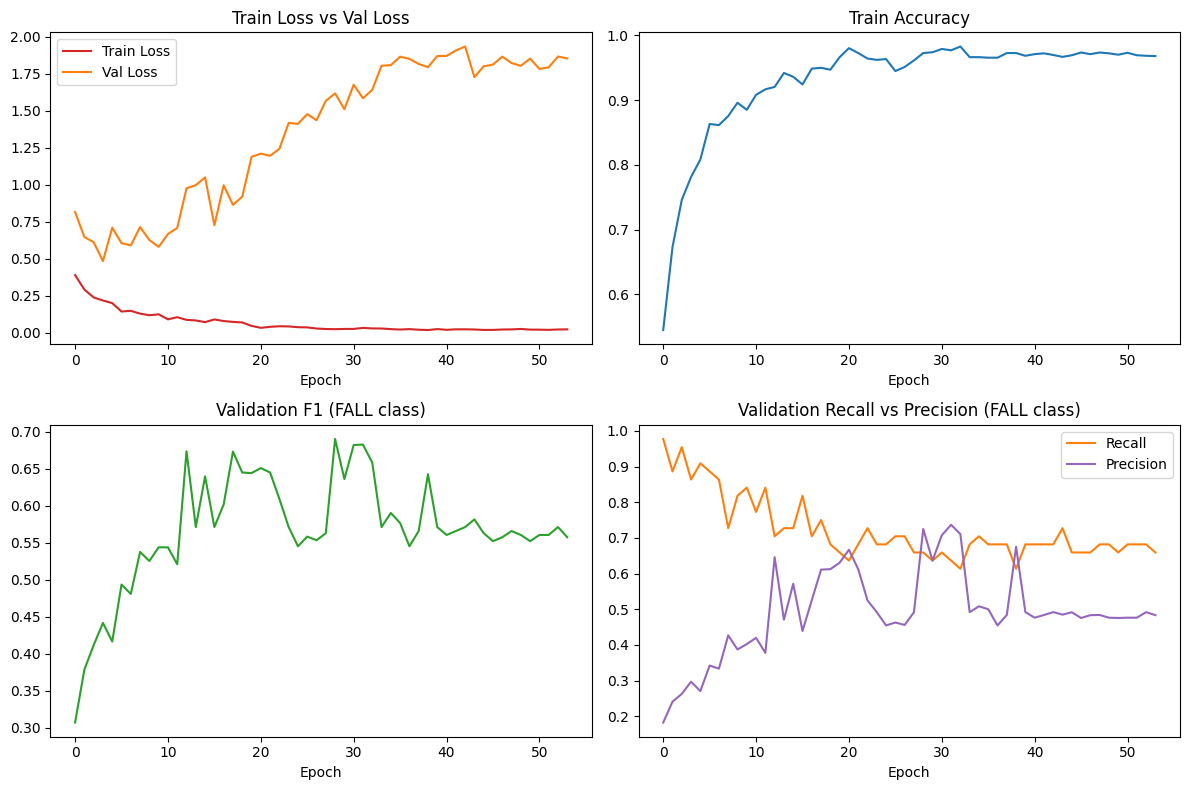

In [16]:
import matplotlib.pyplot as plt

epochs = [h["epoch"] for h in history]
train_loss = [h["train_loss"] for h in history]
val_loss = [h["val_loss"] for h in history]
train_acc = [h["train_acc"] for h in history]
val_f1 = [h["val_f1"] for h in history]
val_recall = [h["val_recall"] for h in history]
val_precision = [h["val_precision"] for h in history]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(epochs, train_loss, label="Train Loss", color='tab:red')
axes[0, 0].plot(epochs, val_loss, label="Val Loss", color='tab:orange')
axes[0, 0].set_title("Train Loss vs Val Loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend()

axes[0, 1].plot(epochs, train_acc, color='tab:blue')
axes[0, 1].set_title("Train Accuracy")
axes[0, 1].set_xlabel("Epoch")

axes[1, 0].plot(epochs, val_f1, color='tab:green')
axes[1, 0].set_title("Validation F1 (FALL class)")
axes[1, 0].set_xlabel("Epoch")

axes[1, 1].plot(epochs, val_recall, label="Recall", color='tab:orange')
axes[1, 1].plot(epochs, val_precision, label="Precision", color='tab:purple')
axes[1, 1].set_title("Validation Recall vs Precision (FALL class)")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

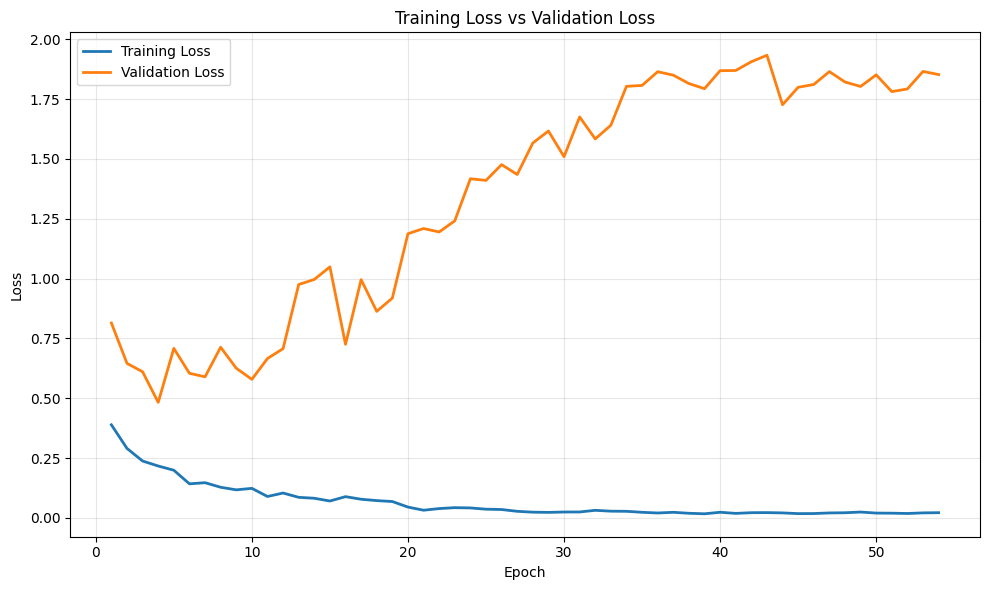

In [17]:
# 1. TRAIN LOSS vs VALIDATION LOSS

import matplotlib.pyplot as plt

epochs = [h["epoch"] + 1 for h in history]

train_loss = [h["train_loss"] for h in history]
val_loss = [h["val_loss"] for h in history]

plt.figure(figsize=(10, 6))

plt.plot(epochs, train_loss, label="Training Loss", linewidth=2)
plt.plot(epochs, val_loss, label="Validation Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Validation Loss")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

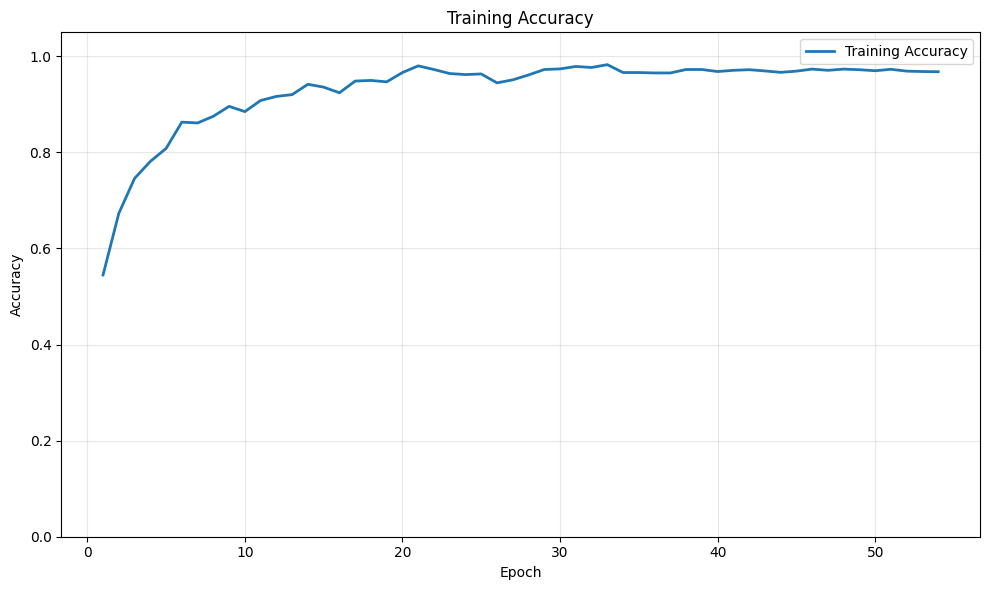

In [18]:
# 2. TRAINING ACCURACY
import matplotlib.pyplot as plt

epochs = [h["epoch"] + 1 for h in history]

train_acc = [h["train_acc"] for h in history]

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    train_acc,
    label="Training Accuracy",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.ylim(0, 1.05)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

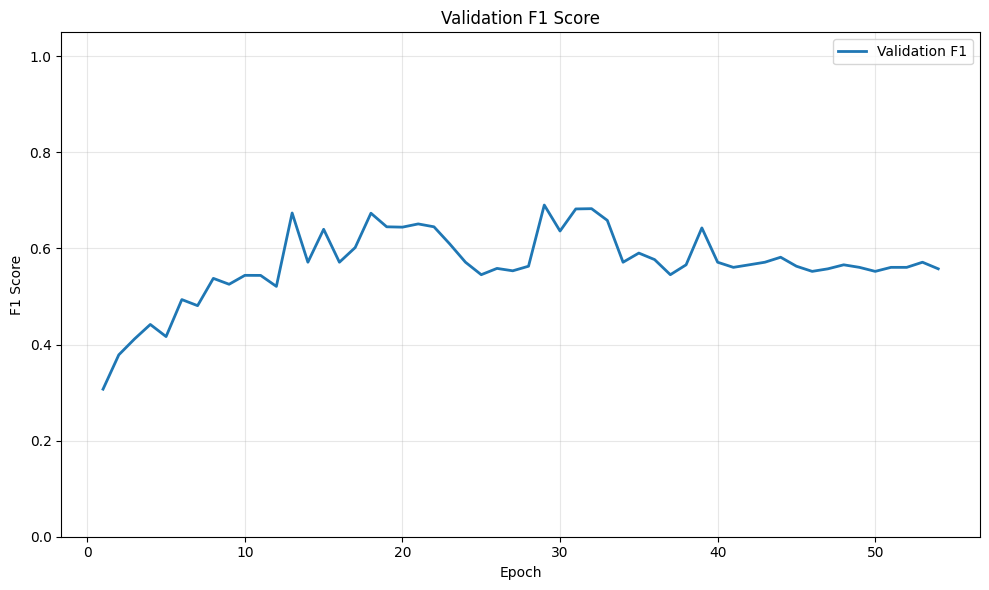

In [19]:
# 3. VALIDATION F1 SCORE
import matplotlib.pyplot as plt

epochs = [h["epoch"] + 1 for h in history]

val_f1 = [h["val_f1"] for h in history]

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    val_f1,
    label="Validation F1",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Validation F1 Score")

plt.ylim(0, 1.05)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

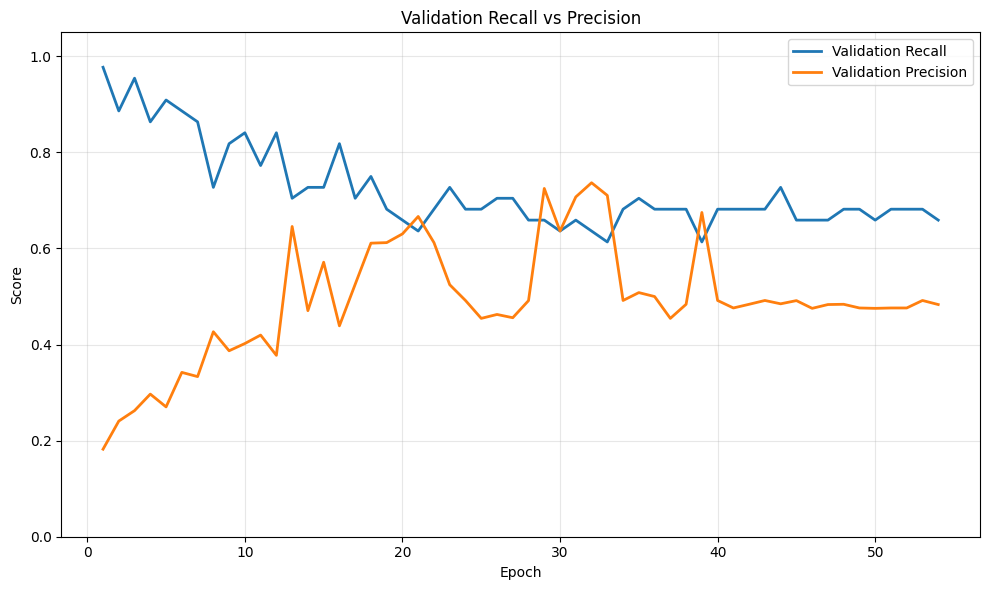

In [20]:
# 4. VALIDATION RECALL vs PRECISION
import matplotlib.pyplot as plt

epochs = [h["epoch"] + 1 for h in history]

val_recall = [h["val_recall"] for h in history]
val_precision = [h["val_precision"] for h in history]

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    val_recall,
    label="Validation Recall",
    linewidth=2
)

plt.plot(
    epochs,
    val_precision,
    label="Validation Precision",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Recall vs Precision")

plt.ylim(0, 1.05)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **OPTION B: FULL REBUILD (only if changing window size, adding a dataset, or re-verifying extraction)**
#### **IMPORTANT**: 
#### After running this block to rebuild X and y, you must manually scroll back UP and re-run cells 6 through 14 (split -> seed -> model -> training -> eval).
#### This block does NOT retrain automatically — Run All only executes top-to-bottom once,
#### and this block sits below the training cells.

In [21]:
def load_fall_annotation(annotation_path):
    """
    Reads the fall start/end frame numbers from an annotation file.
    Some Le2i annotation files have no fall (video is pure ADL) and skip
    straight to bounding-box rows instead of a fall_start/fall_end header —
    in that case, we return (None, None), which downstream code already
    treats as "label everything ADL."
    """
    with open(annotation_path, "r") as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]

    if len(lines) < 2:
        return None, None

    try:
        fall_start = int(lines[0])
        fall_end = int(lines[1])
        return fall_start, fall_end
    except ValueError:
        # first line isn't a plain integer — no fall annotated in this video
        return None, None


def get_frame_label(frame_number, fall_start, fall_end):
    """
    1 = this frame falls inside the annotated fall window, 0 = otherwise.
    """
    if fall_start <= frame_number <= fall_end:
        return 1
    else:
        return 0

In [22]:
import os
import glob

BASE_PATH = "/kaggle/input/datasets/tuyenldvn/falldataset-imvia"


def find_video_annotation_folder_pairs(base_path):
    """
    Walks the dataset tree and finds every (video folder, annotation folder)
    pair that sit as siblings — handles inconsistent naming
    (e.g. 'Annotation_files' vs 'Annotations_files') without hardcoding it.
    """
    pairs = []
    for root, dirs, files in os.walk(base_path):
        video_dirs = [d for d in dirs if "video" in d.lower()]
        annot_dirs = [d for d in dirs if "annotation" in d.lower()]
        if video_dirs and annot_dirs:
            pairs.append({
                "category": os.path.basename(root),
                "video_dir": os.path.join(root, video_dirs[0]),
                "annot_dir": os.path.join(root, annot_dirs[0]),
            })
    return pairs


def build_full_dataset_index(base_path):
    """
    Returns every usable video across all 6 categories:
    - Coffee_room/Home: paired with a real annotation file (has_annotation=True)
    - Lecture_room/Office: no annotation exists at all -> always ADL (has_annotation=False)
    """
    index = []

    # Annotated categories
    for pair in find_video_annotation_folder_pairs(base_path):
        for video_path in sorted(glob.glob(os.path.join(pair["video_dir"], "*.avi"))):
            video_name = os.path.splitext(os.path.basename(video_path))[0]
            annotation_path = os.path.join(pair["annot_dir"], f"{video_name}.txt")
            if os.path.exists(annotation_path):
                index.append({
                    "category": pair["category"],
                    "video_path": video_path,
                    "annotation_path": annotation_path,
                    "has_annotation": True
                })

    # Unannotated categories — explicit paths, no guessing
    UNANNOTATED_DIRS = [
        os.path.join(base_path, "Lecture_room", "Lecture room"),
        os.path.join(base_path, "Office", "Office"),
    ]
    for vid_dir in UNANNOTATED_DIRS:
        if not os.path.exists(vid_dir):
            print(f"⚠️ not found: {vid_dir}")
            continue
        for video_path in sorted(glob.glob(os.path.join(vid_dir, "*.avi"))):
            index.append({
                "category": os.path.basename(vid_dir),
                "video_path": video_path,
                "annotation_path": None,
                "has_annotation": False
            })

    return index


dataset_index = build_full_dataset_index(BASE_PATH)
print(f"Total videos: {len(dataset_index)}")
print(f"  Annotated: {sum(1 for d in dataset_index if d['has_annotation'])}")
print(f"  Unannotated (all ADL): {sum(1 for d in dataset_index if not d['has_annotation'])}")

Total videos: 190
  Annotated: 130
  Unannotated (all ADL): 60


In [23]:
import mediapipe as mp
import cv2
import numpy as np
import subprocess
import os
import shutil

mp_pose = mp.solutions.pose
INPUT_DIM = 33 * 3
FRAME_SKIP_FPS = 12.5  # ffmpeg extracts at this rate directly, instead of skipping frames after the fact
WINDOW_SIZE = 30
STEP_SIZE = 15


def get_pose_model():
    return mp_pose.Pose(
        static_image_mode=True,   # True now — we're processing independent saved images, not a live stream
        model_complexity=1,
        min_detection_confidence=0.3
    )


def extract_keypoints(frame_bgr, pose_model):
    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    result = pose_model.process(rgb)
    if result.pose_landmarks:
        return np.array(
            [[lm.x, lm.y, lm.z] for lm in result.pose_landmarks.landmark],
            dtype=np.float32
        ).flatten()
    return np.zeros(INPUT_DIM, dtype=np.float32)


def extract_frames_ffmpeg(video_path, output_dir, fps=FRAME_SKIP_FPS, timeout=120):
    # Clean the folder first in case leftover files from an interrupted run are sitting here
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir, ignore_errors=True)
    os.makedirs(output_dir, exist_ok=True)

    cmd = [
        "ffmpeg", "-y", "-i", video_path,   # -y: overwrite without prompting, never wait on stdin
        "-vf", f"fps={fps}",
        "-loglevel", "error",
        os.path.join(output_dir, "frame_%05d.jpg")
    ]
    subprocess.run(cmd, check=True, timeout=timeout)  # hard cap so a bad file fails fast instead of hanging


def extract_pose_sequence_from_video(video_path, annotation_path, tmp_dir="/kaggle/working/tmp_frames"):
    """
    1. Extracts frames to disk via ffmpeg (bypasses cv2.VideoCapture entirely)
    2. Runs MediaPipe pose on each saved frame
    3. Labels each frame using the annotation file (or ADL if none exists)
    4. Cleans up the temp frame folder afterward
    """
    fall_start, fall_end = (None, None)
    if annotation_path is not None:
        fall_start, fall_end = load_fall_annotation(annotation_path)

    extract_frames_ffmpeg(video_path, tmp_dir)
    frame_files = sorted(os.listdir(tmp_dir))

    pose_model = get_pose_model()
    results_list = []

    try:
        for i, fname in enumerate(frame_files):
            img = cv2.imread(os.path.join(tmp_dir, fname))
            if img is None:
                continue
            keypoints = extract_keypoints(img, pose_model)
            # frame index in ORIGINAL video timing = i * (25 / 12.5) = i * 2, since we sampled at half rate
            original_frame_number = i * 2
            label = get_frame_label(original_frame_number, fall_start, fall_end) if fall_start is not None else 0
            results_list.append({
                "frame_number": original_frame_number,
                "keypoints": keypoints,
                "label": label
            })
    finally:
        pose_model.close()
        shutil.rmtree(tmp_dir, ignore_errors=True)  # delete temp JPGs so disk doesn't fill up across 190 videos

    return results_list

In [24]:
test_item = dataset_index[0]
result = extract_pose_sequence_from_video(test_item["video_path"], test_item["annotation_path"])

print(f"Total frames processed: {len(result)}")
print(f"Fall-labeled frames: {sum(1 for r in result if r['label'] == 1)}")
print(f"Sample keypoints shape: {result[0]['keypoints'].shape}")

[mp3float @ 0x5ca80b0c4680] Header missing
    Last message repeated 3 times
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1786484240.050223     368 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786484240.083611     368 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Total frames processed: 246
Fall-labeled frames: 14
Sample keypoints shape: (99,)


In [25]:
import os
for root, dirs, files in os.walk("/kaggle/input"):
    print(root, "->", dirs, f"({len(files)} files)")
    if root.count("/") > 5:
        break

/kaggle/input -> ['datasets'] (0 files)
/kaggle/input/datasets -> ['shahliza27', 'sanyaa11', 'tuyenldvn'] (0 files)
/kaggle/input/datasets/shahliza27 -> ['ur-fall-detection-dataset'] (0 files)
/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset -> ['UR_fall_detection_dataset_cam0_rgb'] (0 files)
/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb -> ['adl-07-cam0-rgb', 'adl-32-cam0-rgb', 'adl-28-cam0-rgb', 'fall-29-cam0-rgb', 'fall-24-cam0-rgb', 'fall-07-cam0-rgb', 'fall-16-cam0-rgb', 'adl-02-cam0-rgb', 'adl-35-cam0-rgb', 'fall-11-cam0-rgb', 'fall-18-cam0-rgb', 'fall-06-cam0-rgb', 'fall-15-cam0-rgb', 'adl-20-cam0-rgb', 'fall-28-cam0-rgb', 'adl-31-cam0-rgb', 'adl-24-cam0-rgb', 'adl-18-cam0-rgb', 'adl-38-cam0-rgb', 'adl-40-cam0-rgb', 'adl-10-cam0-rgb', 'adl-19-cam0-rgb', 'adl-17-cam0-rgb', 'adl-34-cam0-rgb', 'adl-33-cam0-rgb', 'fall-17-cam0-rgb', 'adl-05-cam0-rgb', 'adl-12-cam0-rgb', 'adl-23-cam0-rgb', 'adl-16-cam0-rgb', 'fall-21-cam0-rg

In [26]:
import shutil
import os

SRC = "/kaggle/input/datasets/sanyaa11/fall-detection-pose-backup"
DST = "/kaggle/working/pose_data"

os.makedirs(DST, exist_ok=True)

for fname in os.listdir(SRC):
    shutil.copy(os.path.join(SRC, fname), os.path.join(DST, fname))

print(len(os.listdir(DST)))

190


In [27]:
import pickle

POSE_OUTPUT_DIR = "/kaggle/working/pose_data"
os.makedirs(POSE_OUTPUT_DIR, exist_ok=True)


def get_output_path(video_path, category):
    video_id = os.path.splitext(os.path.basename(video_path))[0].replace(" ", "_").replace("(", "").replace(")", "")
    category_clean = category.replace(" ", "_")
    return os.path.join(POSE_OUTPUT_DIR, f"{category_clean}__{video_id}.pkl")


def process_all_videos(dataset_index):
    for idx, item in enumerate(dataset_index):
        out_path = get_output_path(item["video_path"], item["category"])

        if os.path.exists(out_path):
            continue

        print(f"[{idx+1}/{len(dataset_index)}] starting: {item['video_path']}", flush=True)

        try:
            result = extract_pose_sequence_from_video(item["video_path"], item["annotation_path"])
            with open(out_path, "wb") as f:
                pickle.dump({"category": item["category"], "frames": result}, f)
            print(f"[{idx+1}/{len(dataset_index)}] ✅ done — {len(result)} frames, "
                  f"{sum(1 for r in result if r['label']==1)} fall-labeled", flush=True)
        except Exception as e:
            print(f"[{idx+1}/{len(dataset_index)}] ❌ FAILED: {e}", flush=True)


process_all_videos(dataset_index)

In [28]:
import os

POSE_OUTPUT_DIR = "/kaggle/working/pose_data"
saved_files = os.listdir(POSE_OUTPUT_DIR)
print(f"Total saved files: {len(saved_files)}")
print(f"Expected: 190")

Total saved files: 190
Expected: 190


In [29]:
import shutil
shutil.make_archive("/kaggle/working/pose_data_backup", 'zip', "/kaggle/working/pose_data")
print("Zipped — will appear in /kaggle/working/ as pose_data_backup.zip")

Zipped — will appear in /kaggle/working/ as pose_data_backup.zip


In [30]:
# import os

# POSE_OUTPUT_DIR = "/kaggle/working/pose_data"
# all_files = os.listdir(POSE_OUTPUT_DIR)

# # New-format files contain "__" (category__videoid.pkl); old-format ones don't
# old_format = [f for f in all_files if "__" not in f]
# new_format = [f for f in all_files if "__" in f]

# print(f"Old-format files (to delete): {len(old_format)}")
# print(f"New-format files (to keep): {len(new_format)}")

# for f in old_format:
#     os.remove(os.path.join(POSE_OUTPUT_DIR, f))

# remaining = os.listdir(POSE_OUTPUT_DIR)
# print(f"Remaining after cleanup: {len(remaining)}")

In [31]:
import pickle
import os

POSE_OUTPUT_DIR = "/kaggle/working/pose_data"

all_videos = []
for fname in os.listdir(POSE_OUTPUT_DIR):
    with open(os.path.join(POSE_OUTPUT_DIR, fname), "rb") as f:
        data = pickle.load(f)
    all_videos.append(data)

print(f"Loaded {len(all_videos)} videos")
print(f"Example video: category={all_videos[0]['category']}, frames={len(all_videos[0]['frames'])}")

Loaded 190 videos
Example video: category=Coffee_room_02, frames=657


In [32]:
import numpy as np

WINDOW_SIZE = 30
STEP_SIZE = 15

def build_windows(video_data, window_size=WINDOW_SIZE, step=STEP_SIZE):
    """
    Slices one video's frame list into overlapping windows.
    A window is labeled fall (1) if ANY frame inside it is a fall frame —
    biased toward catching partial falls at window boundaries, since a
    missed fall (false negative) is worse than a false alarm here.
    """
    frames = video_data["frames"]
    keypoint_seq = np.array([f["keypoints"] for f in frames])   # (num_frames, 99)
    label_seq = np.array([f["label"] for f in frames])           # (num_frames,)

    windows, window_labels = [], []
    for start in range(0, len(frames) - window_size + 1, step):
        end = start + window_size
        windows.append(keypoint_seq[start:end])
        window_labels.append(1 if label_seq[start:end].any() else 0)

    return windows, window_labels


all_windows, all_labels = [], []
for video_data in all_videos:
    windows, labels = build_windows(video_data)
    all_windows.extend(windows)
    all_labels.extend(labels)

X = np.array(all_windows, dtype=np.float32)
y = np.array(all_labels, dtype=np.int64)

print(f"Total windows: {len(X)}")
print(f"X shape: {X.shape}")   # expect (N, 30, 99)
print(f"Fall windows: {y.sum()} ({y.sum()/len(y)*100:.1f}%)")
print(f"ADL windows: {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%)")

Total windows: 2267
X shape: (2267, 30, 99)
Fall windows: 276 (12.2%)
ADL windows: 1991 (87.8%)


In [33]:
import shutil
import os

SRC = "/kaggle/input/datasets/sanyaa11/urfd-pose-backup"   # confirm exact name from the listdir above
DST = "/kaggle/working/urfd_data"
os.makedirs(DST, exist_ok=True)

for fname in os.listdir(SRC):
    shutil.copy(os.path.join(SRC, fname), os.path.join(DST, fname))

print(len(os.listdir(DST)))

70


In [34]:
from pathlib import Path
import pickle

URFD_PATH = "/kaggle/input/datasets/shahliza27/ur-fall-detection-dataset/UR_fall_detection_dataset_cam0_rgb"
URFD_OUTPUT_DIR = "/kaggle/working/urfd_data"
os.makedirs(URFD_OUTPUT_DIR, exist_ok=True)


def extract_urfd_sequence(folder_path, label):
    """
    URFD sequences are already-extracted PNG frames — no video decoding at all,
    so none of the cv2.VideoCapture crash issues we hit with Le2i apply here.
    """
    frames = sorted(Path(folder_path).glob("*.png"))
    pose_model = get_pose_model()

    results_list = []
    try:
        for i, img_path in enumerate(frames):
            img = cv2.imread(str(img_path))
            if img is None:
                continue
            keypoints = extract_keypoints(img, pose_model)
            results_list.append({"frame_number": i, "keypoints": keypoints, "label": label})
    finally:
        pose_model.close()

    return results_list


urfd_folders = sorted([f for f in Path(URFD_PATH).iterdir() if f.is_dir() and "cam0-rgb" in f.name.lower()])
print(f"URFD sequences to process: {len(urfd_folders)}")

for idx, seq_folder in enumerate(urfd_folders):
    out_path = os.path.join(URFD_OUTPUT_DIR, f"{seq_folder.name}.pkl")

    if os.path.exists(out_path):
        continue  # resume support, same pattern as Le2i

    label = 1 if seq_folder.name.lower().startswith("fall") else 0
    print(f"[{idx+1}/{len(urfd_folders)}] starting: {seq_folder.name}", flush=True)

    try:
        frames = extract_urfd_sequence(seq_folder, label)
        with open(out_path, "wb") as f:
            pickle.dump({"category": seq_folder.name, "frames": frames}, f)
        print(f"[{idx+1}/{len(urfd_folders)}] ✅ done — {len(frames)} frames, label={label}", flush=True)
    except Exception as e:
        print(f"[{idx+1}/{len(urfd_folders)}] ❌ FAILED: {e}", flush=True)

URFD sequences to process: 70


In [35]:
import shutil
shutil.make_archive("/kaggle/working/urfd_data_backup", 'zip', "/kaggle/working/urfd_data")

from IPython.display import FileLink
FileLink('/kaggle/working/urfd_data_backup.zip')

/kaggle/working/urfd_data_backup.zip

In [36]:
import pickle
import os

# Load URFD videos the same way we loaded Le2i
urfd_videos = []
for fname in os.listdir("/kaggle/working/urfd_data"):
    with open(os.path.join("/kaggle/working/urfd_data", fname), "rb") as f:
        urfd_videos.append(pickle.load(f))

print(f"Loaded {len(urfd_videos)} URFD sequences")

# Combine with your existing 190 Le2i videos (all_videos should already be in memory)
combined_videos = all_videos + urfd_videos
print(f"Combined total: {len(combined_videos)} videos ({len(all_videos)} Le2i + {len(urfd_videos)} URFD)")

# Rebuild windows from the combined set — reuses build_windows exactly as before
all_windows, all_labels = [], []
for video_data in combined_videos:
    windows, labels = build_windows(video_data)
    all_windows.extend(windows)
    all_labels.extend(labels)

X = np.array(all_windows, dtype=np.float32)
y = np.array(all_labels, dtype=np.int64)

print(f"Total windows: {len(X)}")
print(f"X shape: {X.shape}")
print(f"Fall windows: {y.sum()} ({y.sum()/len(y)*100:.1f}%)")
print(f"ADL windows: {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%)")

Loaded 70 URFD sequences
Combined total: 260 videos (190 Le2i + 70 URFD)
Total windows: 2967
X shape: (2967, 30, 99)
Fall windows: 433 (14.6%)
ADL windows: 2534 (85.4%)


In [37]:
shutil.copy('/kaggle/working/fall_lstm_best.pt', '/kaggle/working/fall_lstm_combined_F1_0.742.pt')

np.save('/kaggle/working/X_combined.npy', X)
np.save('/kaggle/working/y_combined.npy', y)

import zipfile
with zipfile.ZipFile('/kaggle/working/final_backup.zip', 'w') as zf:
    zf.write('/kaggle/working/fall_lstm_best.pt', 'fall_lstm_best.pt')
    zf.write('/kaggle/working/norm_mean.npy', 'norm_mean.npy')
    zf.write('/kaggle/working/norm_std.npy', 'norm_std.npy')
    zf.write('/kaggle/working/X_combined.npy', 'X_combined.npy')
    zf.write('/kaggle/working/y_combined.npy', 'y_combined.npy')

from IPython.display import FileLink
FileLink('/kaggle/working/final_backup.zip')

/kaggle/working/final_backup.zip

In [38]:
import os
print(os.path.exists('/kaggle/working/final_backup.zip'))
print(f"{os.path.getsize('/kaggle/working/final_backup.zip') / (1024*1024):.1f} MB")

True
34.4 MB
